In [3]:
import os
from google.colab import drive
from tqdm.auto import tqdm

unzipped_images_dir = '/content/my_images/extract'
zip_path = '/content/drive/MyDrive/Colab Notebooks/extract.zip'
expected_image_count = 30550 # Updated based on user instruction

def count_files_with_progress(directory, description):
    file_count = 0
    # Use tqdm to show progress for iterating through directories
    for root, dirs, files in tqdm(os.walk(directory), desc=description, unit="dir"):
        file_count += len(files)
    return file_count

# Check if images are already extracted
if os.path.exists(unzipped_images_dir) and os.listdir(unzipped_images_dir):
    current_image_count = count_files_with_progress(unzipped_images_dir, "Counting existing images")
    if current_image_count == expected_image_count:
        print(f"✅ Images already extracted to {unzipped_images_dir}. Skipping extraction. ({current_image_count} files found)")
    else:
        print(f"⚠️ Images directory {unzipped_images_dir} exists but contains {current_image_count} files instead of the expected {expected_image_count}.")
        user_response = input("Do you want to re-extract the images? (yes/no): ").strip().lower()
        if user_response == 'yes':
            print("Proceeding with re-extraction...")
            # Force re-extraction if count is wrong
            drive.mount('/content/drive')
            if os.path.exists(zip_path):
                print("✅ Zip file found! Starting re-extraction...")
                os.makedirs('/content/my_images', exist_ok=True)
                !unzip -o -q "{zip_path}" -d /content/my_images # Use -o to overwrite existing files
                final_image_count = count_files_with_progress(unzipped_images_dir, "Counting re-extracted images")
                if final_image_count == expected_image_count:
                    print(f"🎉 Re-extraction complete and verified! ({final_image_count} files found)")
                else:
                    print(f"❌ Re-extraction complete, but found {final_image_count} files instead of {expected_image_count}.")
            else:
                print(f"❌ Error: Zip file not found at {zip_path}")
                print("Double check if there is a typo in 'Colab Notebooks' or the filename.")
        else:
            print(f"Skipping re-extraction. Using existing images ({current_image_count} files).")
else:
    print(f"Images not found in {unzipped_images_dir}. Proceeding with extraction...")
    # 1. Mount the drive (it will ask for permission if not already mounted)
    drive.mount('/content/drive')

    # 2. Check if the zip file actually exists at that path before unzipping
    if os.path.exists(zip_path):
        print("✅ Zip file found! Starting extraction...")
        # 3. Create the target directory if it doesn't exist
        os.makedirs('/content/my_images', exist_ok=True)
        # 4. Unzip to the local 'content' folder (fast SSD)
        # -q means 'quiet' so it doesn't print 10,000 lines
        !unzip -q "{zip_path}" -d /content/my_images

        # 5. Verify extraction count
        final_image_count = count_files_with_progress(unzipped_images_dir, "Counting extracted images")
        if final_image_count == expected_image_count:
            print(f"🎉 Extraction complete and verified! ({final_image_count} files found)")
        else:
            print(f"❌ Extraction complete, but found {final_image_count} files instead of {expected_image_count}.")
    else:
        print(f"❌ Error: Zip file not found at {zip_path}")
        print("Double check if there is a typo in 'Colab Notebooks' or the filename.")

Counting existing images: 0dir [00:00, ?dir/s]

✅ Images already extracted to /content/my_images/extract. Skipping extraction. (30550 files found)


In [4]:
!ls

drive  my_images  sample_data


In [5]:
!cp /content/drive/MyDrive/Colab Notebooks/extract.zip /content/

cp: cannot stat '/content/drive/MyDrive/Colab': No such file or directory
cp: cannot stat 'Notebooks/extract.zip': No such file or directory


In [6]:
!find /content/my_images/extract -type f | wc -l

30550


In [7]:
from pathlib import Path

IMAGES_PATH = Path("/content/my_images/extract")

def index_labeled_images(images_path=IMAGES_PATH, max_per_class=3000):
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        count = 0
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            if count >= max_per_class:
                break
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }
            count += 1

    return labeled_images

In [8]:
labeled_images = index_labeled_images()

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm.auto import tqdm

def extract_labels(labeled_images):
    labels = []
    paths = []
    for (i, image_name) in enumerate(labeled_images):
        path = labeled_images[image_name]['path']
        paths.append(path)
        label = labeled_images[image_name]['label']
        labels.append(label)

    return paths, np.array(labels)

In [10]:
paths, labels = extract_labels(labeled_images)

In [11]:
print(labels)

['Ac' 'Ac' 'Ac' ... 'St' 'St' 'St']


In [12]:
print(paths)

['/content/my_images/extract/Ac/101-125549-20826653-201909061746_GE_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061746_GN_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061746_GS_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061746_GU_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061746_GW_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061813_GE_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061813_GN_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061813_GS_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061813_GU_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201909061813_GW_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201911051745_GE_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201911051745_GN_Ac.jpg', '/content/my_images/extract/Ac/101-125549-20826653-201911051745_GS_Ac.jpg', '/content/m

In [13]:
import torch

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [14]:
# augmentation

import torch
import torchvision.transforms.v2 as T
from torchvision.transforms.v2 import InterpolationMode

def color_jitter_if_rgb(x):
    return T.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.15, hue=0.02)(x) if x.ndim == 3 and x.shape[0] == 3 else x

IMG_SIZE = (224, 224)  # required by ViT_B_16 SWAG weights
MAX_FRAC = 0.14

border_translation = T.RandomAffine(
    degrees=0,
    translate=(MAX_FRAC, MAX_FRAC),
    interpolation=InterpolationMode.BILINEAR,
    fill=0
)

wrap_translation = T.Lambda(lambda x: torch.roll(
    x,
    shifts=(
        int(torch.randint(-int(MAX_FRAC * x.shape[-2]), int(MAX_FRAC * x.shape[-2]) + 1, (1,)).item()),
        int(torch.randint(-int(MAX_FRAC * x.shape[-1]), int(MAX_FRAC * x.shape[-1]) + 1, (1,)).item()),
    ),
    dims=(-2, -1),
))

stacked = T.Compose([
    T.RandomChoice([wrap_translation, border_translation]),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.15),
    T.RandomAffine(
        degrees=20, scale=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR, fill=0
    ),
    T.RandomResizedCrop(
        size=IMG_SIZE, scale=(0.80, 1.00), ratio=(0.90, 1.10),
        interpolation=InterpolationMode.BILINEAR
    ),
])

one_of = T.RandomChoice([
    wrap_translation,
    border_translation,
    T.RandomChoice([T.RandomHorizontalFlip(p=1.0), T.RandomVerticalFlip(p=1.0)]),
    T.RandomRotation(degrees=20, interpolation=InterpolationMode.BILINEAR, fill=0),
])

normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomChoice([stacked, one_of]),
    normalize,
])

eval_transforms = T.Compose([
    T.Resize(IMG_SIZE, interpolation=InterpolationMode.BILINEAR),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    normalize,
])

In [15]:
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
from functools import partial

In [16]:
torchvision.models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [17]:
list(torchvision.models.get_model_weights("vit_b_16"))

[ViT_B_16_Weights.IMAGENET1K_V1,
 ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1,
 ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1]

In [18]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_LINEAR_V1
model = torchvision.models.vit_b_16(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16_lc_swag-4e70ced5.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_lc_swag-4e70ced5.pth


100%|██████████| 330M/330M [00:01<00:00, 235MB/s]


In [19]:
import torchvision.transforms.v2 as T

transforms = weights.transforms()
# transforms = T.Compose([
#     T.RandomHorizontalFlip(p=0.5),
#     T.RandomRotation(degrees=30),
#     T.RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0)),
#     T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     T.ToImage(),
#     T.ToDtype(torch.float32, scale=True),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])

In [20]:
print(transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[224]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [21]:
from sklearn.preprocessing import LabelEncoder

def encode_labels(labels):
    ordinal_encoder = LabelEncoder()
    encoded_labels = ordinal_encoder.fit_transform(labels)
    class_names = ordinal_encoder.classes_
    return encoded_labels, class_names


In [22]:
encoded_labels, class_names = encode_labels(labels)

In [23]:
print(class_names)

['Ac' 'As' 'Cb' 'Cc' 'Ci' 'ClSk' 'Cs' 'Ct' 'Cu' 'Ns' 'Sc' 'St']


In [24]:
print(encoded_labels)

[ 0  0  0 ... 11 11 11]


In [25]:
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedShuffleSplit
from PIL import Image
import numpy as np

class MyImages(Dataset):
    def __init__(self, paths, encoded_labels, split="train", test_size=0.2, val_size=0.1, random_state=42, transform=None,
                 split_indices=None):

        if split not in {None, "train", "val", "test"}:
            raise ValueError(f"split must be one of {{'None','train','val','test'}}, got {split!r}")

        self.transform = transform

        paths = np.array(list(paths))
        encoded_labels = np.array(list(encoded_labels))

        n = len(paths)
        if n != len(encoded_labels):
            raise ValueError(f"paths and encoded_labels must have same length, got {n} and {len(labels)}")

        if split_indices is None:
            sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
            trainval_idx, test_idx = next(sss1.split(paths, encoded_labels))

            trainval_fraction = 1.0 - test_size
            val_within_trainval = val_size / trainval_fraction

            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_within_trainval, random_state=random_state)

            trainval_paths = paths[trainval_idx]
            trainval_labels = encoded_labels[trainval_idx]

            train_rel_idx, val_rel_idx = next(sss2.split(trainval_paths, trainval_labels))
            train_idx = trainval_idx[train_rel_idx]
            val_idx = trainval_idx[val_rel_idx]

            split_indices = {"train": train_idx, "val": val_idx, "test": test_idx}

        idx = split_indices[split]

        self.paths = paths[idx].tolist()
        self.encoded_labels = encoded_labels[idx].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.encoded_labels[idx]


In [26]:
from functools import partial

DefaultCloudImages = partial(
    MyImages,
    paths=paths,
    encoded_labels=encoded_labels,
    transform=transforms,
    test_size=0.2,
    val_size=0.1,
    random_state=42
)

In [27]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

paths_arr = np.array(list(paths))
labels_arr = np.array(list(encoded_labels))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(sss1.split(paths_arr, labels_arr))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.1/0.8, random_state=42)
train_rel_idx, val_rel_idx = next(sss2.split(paths_arr[trainval_idx], labels_arr[trainval_idx]))

split_indices = {
    "train": trainval_idx[train_rel_idx],
    "val":   trainval_idx[val_rel_idx],
    "test":  test_idx,
}

train_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="train", transform=train_transforms,
                     split_indices=split_indices)

valid_set = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="val", transform=eval_transforms,
                     split_indices=split_indices)

test_set  = MyImages(paths=paths, encoded_labels=encoded_labels,
                     split="test", transform=eval_transforms,
                     split_indices=split_indices)

In [28]:
train_set[0]

(tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1062,  ..., -2.1179, -2.1179, -2.1179],
          [-1.9078, -1.7935, -1.6040,  ..., -2.1179, -2.1179, -2.1179],
          ...,
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
          [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],
 
         [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0242,  ..., -2.0357, -2.0357, -2.0357],
          [-1.8209, -1.7057, -1.5246,  ..., -2.0357, -2.0357, -2.0357],
          ...,
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
          [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],
 
         [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
          [-1.8044, -1.8044,

In [29]:
len(train_set)
len(valid_set)
len(test_set)

6110

In [30]:
display_transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500),
])

# create a dataset instance for the train split (use MyImages to request a split)
clouds_to_display = DefaultCloudImages(split="train", transform=display_transform)


In [31]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

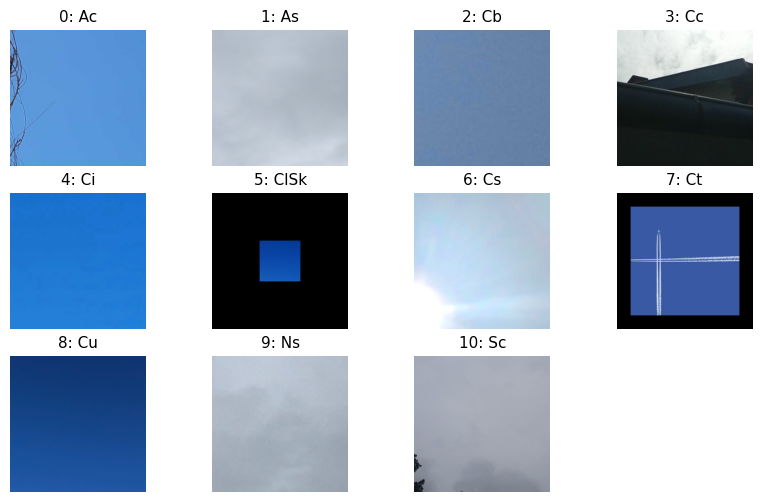

In [32]:
sample_clouds = {}
for img, y in clouds_to_display:
    if y not in sample_clouds:
        sample_clouds[y] = img
    if len(sample_clouds) == len(class_names):
        break

sample_clouds = sorted(sample_clouds.items())[:11]

plt.figure(figsize=(10, 6))
for class_id, image in sample_clouds:
    if class_id == 11: break
    plt.subplot(3, 4, class_id + 1)
    plot_image(image)
    plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [33]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

train_labels_list = [train_set.encoded_labels[i] for i in range(len(train_set))]
class_counts = np.bincount(train_labels_list)
class_weights = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[l] for l in train_labels_list], dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Added num_workers and pin_memory to speed up data loading
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)


In [34]:
[name for name, child in model.named_children()]

['conv_proj', 'encoder', 'heads']

In [35]:
model.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [36]:
model.encoder

Encoder(
  (dropout): Dropout(p=0.0, inplace=False)
  (layers): Sequential(
    (encoder_layer_0): EncoderBlock(
      (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
      (dropout): Dropout(p=0.0, inplace=False)
      (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLPBlock(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.0, inplace=False)
        (3): Linear(in_features=3072, out_features=768, bias=True)
        (4): Dropout(p=0.0, inplace=False)
      )
    )
    (encoder_layer_1): EncoderBlock(
      (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (self_attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
      )
    

In [37]:
model.conv_proj

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

In [38]:
n_classes = 12
model.heads[0] = nn.Linear(768, n_classes).to(device)


In [39]:
for param in model.parameters():
    param.requires_grad = False

for param in model.heads.parameters():
    param.requires_grad = True

In [40]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 60.9 MB/s eta 0:00:00


In [41]:
import torchmetrics
from tqdm.auto import tqdm

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        # Wrap train_loader with tqdm to show a progress bar
        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


In [42]:
n_epochs = 10
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=12).to(device)

for i in range(30):
    print("Run #{}".format(i + 1))
    history = train(model, optimizer, xentropy, accuracy,
                    train_loader, valid_loader, n_epochs)
    print(evaluate_tm(model, test_loader, accuracy))


Run #1


Epoch 1/10:   0%|          | 0/669 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)
evaluate_tm(model, test_loader, accuracy)

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)
# evaluate_tm(model, test_loader, accuracy)

In [ ]:
# for param in model.encoder.layers[-1].parameters():
#     param.requires_grad = True

# evaluate_tm(model, test_loader, accuracy)

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)

In [ ]:
# history = train(model, optimizer, xentropy, accuracy,
#                 train_loader, valid_loader, n_epochs)

In [ ]:
# evaluate_tm(model, test_loader, accuracy)